# Plant Leaf Diseases Classification CNN (PyTorch Implementation)
This notebook trains a deep learning model using high-performance PyTorch paradigms to fully utilize GPU acceleration with Mixed Precision training.
## 1. Imports and GPU Setup
We use `torch.amp` for mixed precision and optimized CUDA operations.

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
import time
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

# ----------------------------------------------------
# 1. GPU CONFIGURATION & DEVICE SETUP
# ----------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    # Enable benchmark for faster execution when input sizes are constant
    torch.backends.cudnn.benchmark = True
else:
    print("No GPU found. Using CPU.")

# Mixed Precision Scaler
scaler = torch.amp.GradScaler('cuda')

Using device: cuda
GPU: NVIDIA GeForce GTX 1650 Ti


## 2. Exploratory Data Analysis (EDA)
Visual inspection of the dataset distribution.

Total Classes: 39
Total Images: 51532


C:\Users\sanja\AppData\Local\Temp\ipykernel_22920\3599273330.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.values()), y=list(class_counts.keys()), palette='viridis')


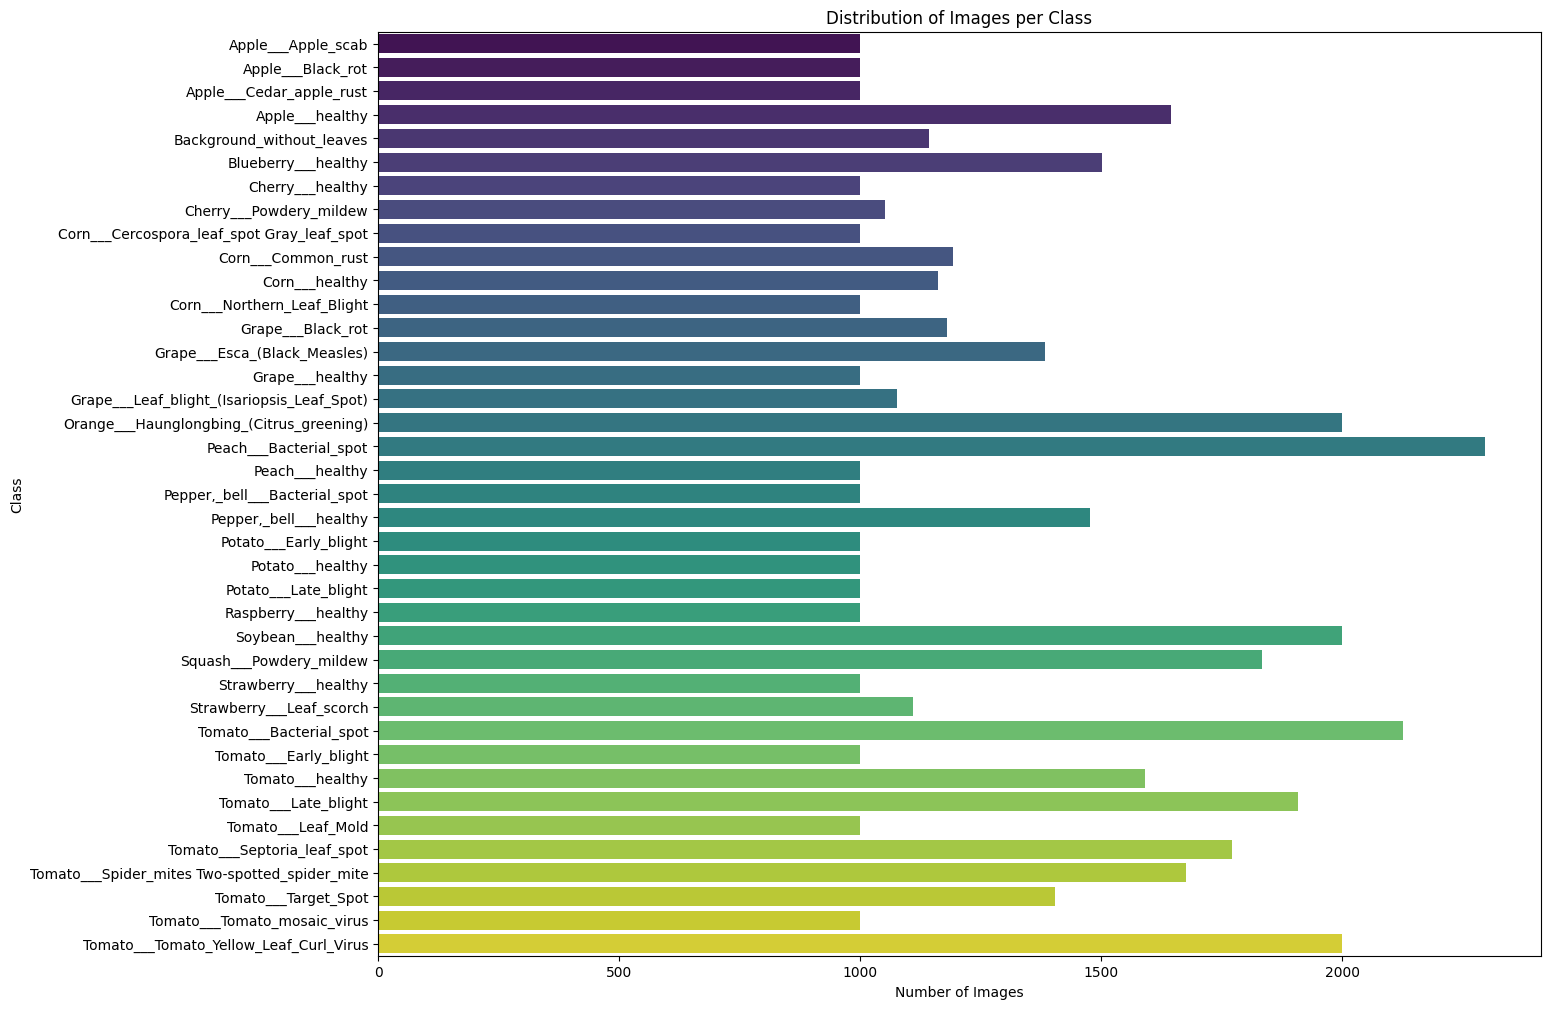

In [8]:
DATASET_DIR = '../DATASET/Augmentated/Plant_leave_diseases_dataset_with_augmentation'

class_counts = {}
for count_dir in os.listdir(DATASET_DIR):
    dir_path = os.path.join(DATASET_DIR, count_dir)
    if os.path.isdir(dir_path):
        class_counts[count_dir] = len(os.listdir(dir_path))

print(f'Total Classes: {len(class_counts)}')
print(f'Total Images: {sum(class_counts.values())}')

plt.figure(figsize=(15, 12))
sns.barplot(x=list(class_counts.values()), y=list(class_counts.keys()), palette='viridis')
plt.title('Distribution of Images per Class')
plt.xlabel('Number of Images')
plt.ylabel('Class')
plt.show()

## 3. High-Performance Preprocessing Pipeline
Using `torchvision.transforms` and `DataLoader` for data loading.

In [9]:
# --- Hyperparameters & Transforms ---
IMAGE_SIZE = 224
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 1. Load the dataset using ImageFolder (to get class mapping)
full_dataset = datasets.ImageFolder(DATASET_DIR)
class_names = full_dataset.classes
num_classes = len(class_names)
print(f"Total classes: {num_classes}")

# 2. Stratified split (80% train, 20% val per folder)
indices = list(range(len(full_dataset)))
targets = full_dataset.targets

train_indices, val_indices = train_test_split(
    indices, 
    test_size=0.2, 
    stratify=targets, 
    random_state=123
)

train_subset = Subset(full_dataset, train_indices)
val_subset = Subset(full_dataset, val_indices)

print(f"Training samples: {len(train_subset)}")
print(f"Validation samples: {len(val_subset)}")

class SubsetWithTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)

train_ds = SubsetWithTransform(train_subset, transform=train_transforms)
val_ds = SubsetWithTransform(val_subset, transform=val_transforms)

# Dataloaders - num_workers set to 0 for Windows compatibility to avoid hangs
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print(f'Total Classes: {num_classes}')
print(f'Train Samples: {len(train_ds)}')
print(f'Validation Samples: {len(val_ds)}')

Total classes: 39
Training samples: 41225
Validation samples: 10307
Total Classes: 39
Train Samples: 41225
Validation Samples: 10307


In [10]:
# Handling Imbalance with Class Weights
labels = full_dataset.targets
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights_tensor = torch.tensor(class_weights_arr, dtype=torch.float).to(device)
print('Class weights computed and moved to device.')

Class weights computed and moved to device.


## 4. Model Architecture (MobileNetV2)
Using transfer learning with a frozen base and a custom head.

In [11]:
class PlantDiseaseModel(nn.Module):
    def __init__(self, num_classes):
        super(PlantDiseaseModel, self).__init__()
        # Load pretrained MobileNetV2
        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')
        
        # Freeze base parameters
        for param in self.base_model.parameters():
            param.requires_grad = False
            
        # Replace the classifier (head)
        self.base_model.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(1280, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        return self.base_model(x)

model = PlantDiseaseModel(num_classes).to(device)
print(f"Model initialized with {num_classes} output classes.")

Model initialized with 39 output classes.


## 5. Training Pipeline
Implementing the training and validation loops with Mixed Precision support.

In [12]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.base_model.classifier.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6)

class EarlyStopping:
    def __init__(self, patience=3, path='best_model.pth'):
        self.patience = patience
        self.path = path
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)

def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for inputs, labels in tqdm(loader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    return running_loss / total, correct / total

def validate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Validation"):
            inputs, labels = inputs.to(device), labels.to(device)
            
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    return running_loss / total, correct / total

In [13]:
EPOCHS = 30
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
early_stopping = EarlyStopping(patience=3, path='cnn_mobilenet_pytorch.pt')

print("Starting accelerated training...")
for epoch in range(EPOCHS):
    t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
    v_loss, v_acc = validate(model, val_loader, criterion)
    
    scheduler.step(v_loss)
    early_stopping(v_loss, model)
    
    history['train_loss'].append(t_loss)
    history['train_acc'].append(t_acc)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {t_loss:.4f}, Train Acc: {t_acc:.4f}")
    print(f"Val Loss: {v_loss:.4f}, Val Acc: {v_acc:.4f}")

    if early_stopping.early_stop:
        print("Early stopping triggered.")
        break

Starting accelerated training...


Validation: 100%|██████████| 323/323 [03:09<00:00,  1.70it/s]


Epoch 1/30
Train Loss: 0.5434, Train Acc: 0.8526
Val Loss: 0.1876, Val Acc: 0.9401


Validation: 100%|██████████| 323/323 [00:39<00:00,  8.18it/s]


Epoch 2/30
Train Loss: 0.3272, Train Acc: 0.8929
Val Loss: 0.1570, Val Acc: 0.9487


...

Epoch 11/30
Train Loss: 0.2496, Train Acc: 0.9166
Val Loss: 0.1104, Val Acc: 0.9635


Validation: 100%|██████████| 323/323 [00:41<00:00,  7.77it/s]


Epoch 12/30
Train Loss: 0.2406, Train Acc: 0.9187
Val Loss: 0.1128, Val Acc: 0.9629


Validation: 100%|██████████| 323/323 [00:37<00:00,  8.72it/s]

Epoch 13/30
Train Loss: 0.2419, Train Acc: 0.9170
Val Loss: 0.1446, Val Acc: 0.9661
Early stopping triggered.


## 6. Evaluation, Results, and Plotting

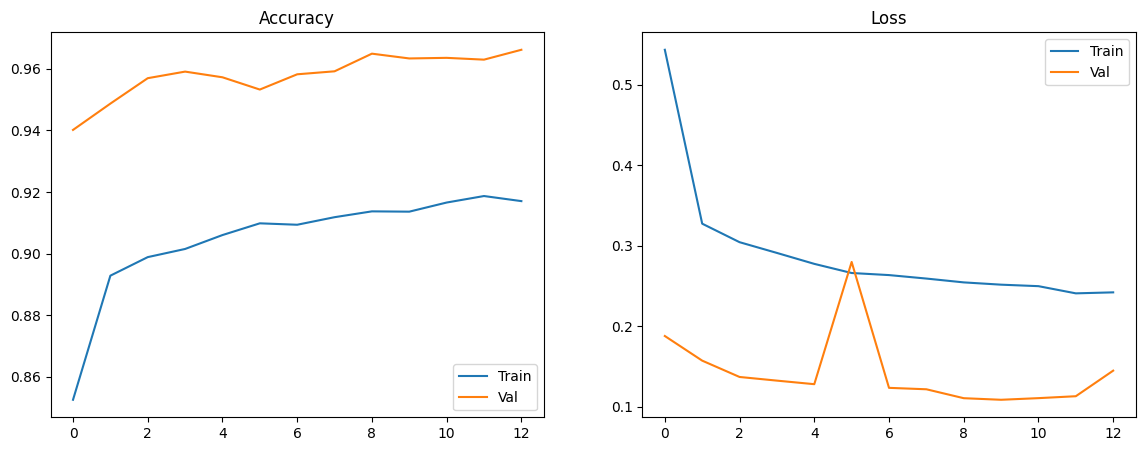

In [14]:
def plot_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    ax[0].plot(history['train_acc'], label='Train')
    ax[0].plot(history['val_acc'], label='Val')
    ax[0].set_title('Accuracy'); ax[0].legend()
    ax[1].plot(history['train_loss'], label='Train')
    ax[1].plot(history['val_loss'], label='Val')
    ax[1].set_title('Loss'); ax[1].legend()
    plt.show()

plot_history(history)

## 7. Saving the Model

In [15]:
MODEL_SAVE_PATH = 'cnn_mobilenet_pytorch_final.pt'
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f'Model securely saved to {MODEL_SAVE_PATH}')

Model securely saved to cnn_mobilenet_pytorch_final.pt


## 8. Model Inference & Visualization
Visualize predictions on random images from the dataset (one diseased and one healthy).

Testing with Random Diseased Leaf...


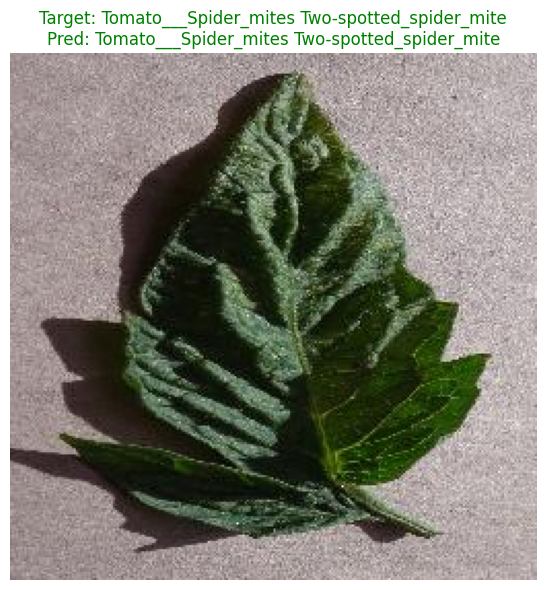


Testing with Random Normal (Healthy) Leaf...


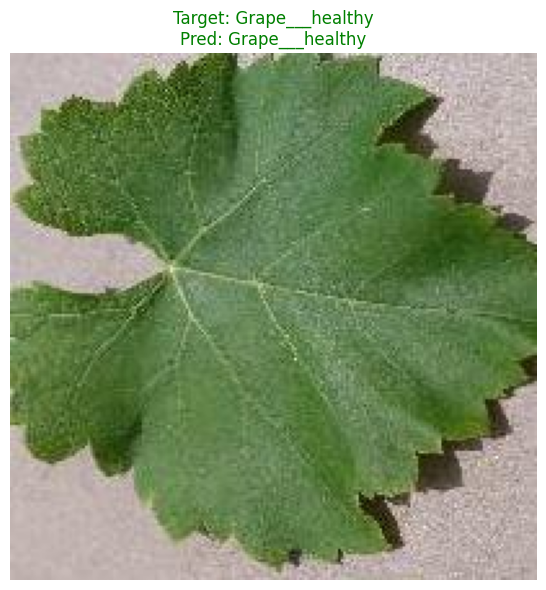

In [102]:
import random
from PIL import Image

def predict_and_plot(model, class_names, transform, device, num_samples=1, target_type='diseased'):
    """
    Picks random images of a specific type (diseased/healthy) and visualizes predictions.
    """
    model.eval()
    
    if target_type == 'healthy':
        # Standard naming convention for healthy classes in this dataset
        filtered_classes = [c for c in class_names if 'healthy' in c.lower()]
    else:
        # Diseased classes (anything that doesn't have 'healthy')
        filtered_classes = [c for c in class_names if 'healthy' not in c.lower()]
    
    if not filtered_classes:
        print(f"No classes found matching type: {target_type}")
        return

    plt.figure(figsize=(12, 6))
    
    for i in range(num_samples):
        # 1. Select random class and image
        random_class = random.choice(filtered_classes)
        class_path = os.path.join(DATASET_DIR, random_class)
        random_img_name = random.choice(os.listdir(class_path))
        img_path = os.path.join(class_path, random_img_name)
        
        # 2. Load and Preprocess
        img = Image.open(img_path).convert('RGB')
        img_tensor = transform(img).unsqueeze(0).to(device)
        
        # 3. Model Inference
        with torch.no_grad():
            outputs = model(img_tensor)
            _, predicted = torch.max(outputs, 1)
            pred_class = class_names[predicted.item()]
            
        # 4. Plot Result
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        
        # Green title if correct, Red if wrong
        title_color = 'green' if pred_class == random_class else 'red'
        plt.title(f"Target: {random_class}\nPred: {pred_class}", color=title_color)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# --- RUN PREDICTIONS ---

print("Testing with Random Diseased Leaf...")
predict_and_plot(model, class_names, val_transforms, device, target_type='diseased')

print("\nTesting with Random Normal (Healthy) Leaf...")
predict_and_plot(model, class_names, val_transforms, device, target_type='healthy')


## 9. Evaluation Metrics & Confusion Matrix
Calculate the precise precision, recall, and f1-score for all 39 classes, and plot a comprehensive confusion matrix.

Evaluating model on validation set... This might take a minute.

--- Classification Report ---
                                               precision    recall  f1-score   support

                           Apple___Apple_scab       0.95      0.97      0.96       200
                            Apple___Black_rot       0.97      0.99      0.98       200
                     Apple___Cedar_apple_rust       0.98      1.00      0.99       200
                              Apple___healthy       0.99      0.97      0.98       329
                    Background_without_leaves       0.99      1.00      0.99       229
                          Blueberry___healthy       0.98      1.00      0.99       300
                      Cherry___Powdery_mildew       0.99      0.99      0.99       210
                             Cherry___healthy       1.00      0.99      1.00       200
   Corn___Cercospora_leaf_spot Gray_leaf_spot       0.88      0.94      0.91       200
                           Corn___

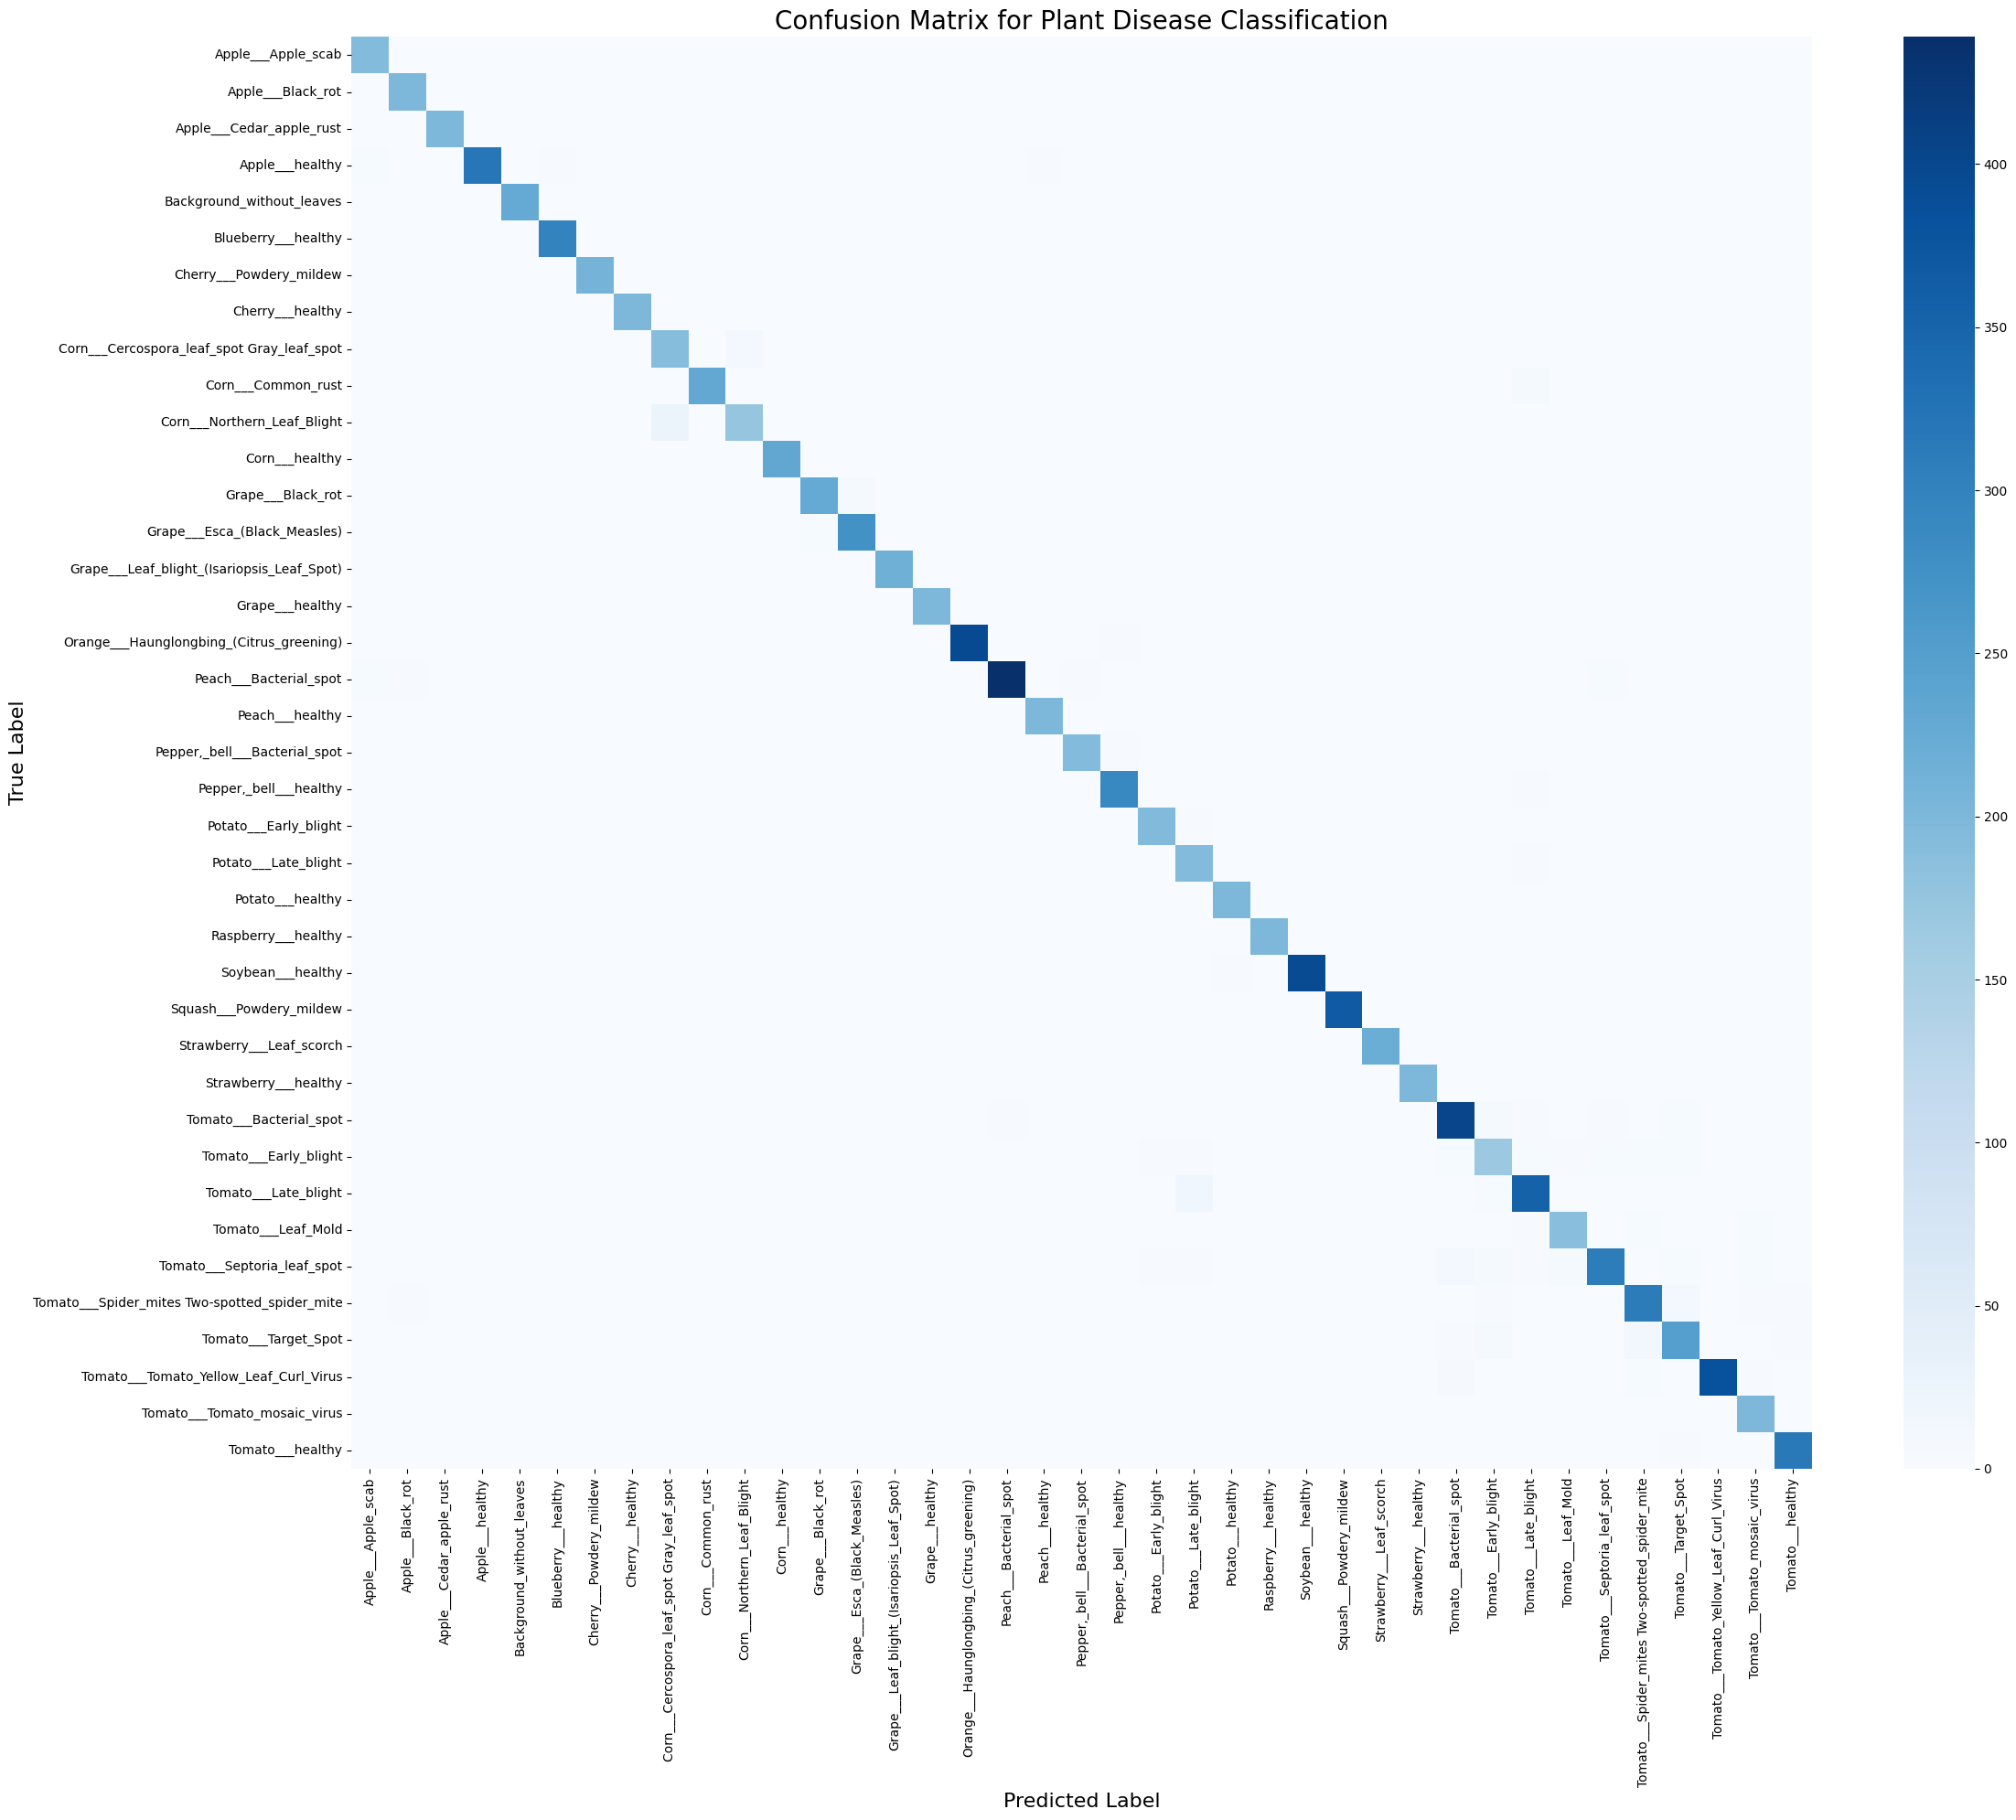

In [17]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(model, loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    print("Evaluating model on validation set... This might take a minute.")
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
            
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # 1. Classification Report
    print("\n--- Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))
    
    # 2. Confusion Matrix
    print("\n--- Confusion Matrix ---")
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(24, 20))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label', fontsize=16)
    plt.ylabel('True Label', fontsize=16)
    plt.title('Confusion Matrix for Plant Disease Classification', fontsize=20)
    plt.xticks(rotation=90, fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()

# --- RUN EVALUATION ---
evaluate_model(model, val_loader, device, class_names)
